In [1]:
import pandas as pd

df = pd.read_csv("../data/ed_throughput.csv")
df.head()

C:\Users\rudy\AppData\Local\Temp\ipykernel_21992\3819055473.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ed_throughput.csv")


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Condition,Measure ID,Measure Name,Score,Sample,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Emergency Department,EDV,Emergency department volume,high,NaN,NaN,01/01/2023,12/31/2023
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS,Global Malnutrition Composite Score,Not Available,Not Available,5,01/01/2024,12/31/2024
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS_Malnutrition_Diagnosis_Documented,Global Malnutrition Composite Score: Malnutrit...,Not Available,Not Available,5,01/01/2024,12/31/2024
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS_Malnutrition_Screening,Global Malnutrition Composite Score: Malnutrit...,Not Available,Not Available,5,01/01/2024,12/31/2024
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS_Nutrition_Assessment,Global Malnutrition Composite Score: Nutrition...,Not Available,Not Available,5,01/01/2024,12/31/2024


In [2]:
df.shape

(138182, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138182 entries, 0 to 138181
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Facility ID       138182 non-null  object
 1   Facility Name     138182 non-null  object
 2   Address           138182 non-null  object
 3   City/Town         138182 non-null  object
 4   State             138182 non-null  object
 5   ZIP Code          138182 non-null  int64 
 6   County/Parish     138182 non-null  object
 7   Telephone Number  138182 non-null  object
 8   Condition         138182 non-null  object
 9   Measure ID        138182 non-null  object
 10  Measure Name      138182 non-null  object
 11  Score             137298 non-null  object
 12  Sample            133523 non-null  object
 13  Footnote          92297 non-null   object
 14  Start Date        138182 non-null  object
 15  End Date          138182 non-null  object
dtypes: int64(1), object(15)
memory usage: 

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

df.head().T

,0,1,2,3,4
Facility ID,010001,010001,010001,010001,010001
Facility Name,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER
Address,1108 ROSS CLARK CIRCLE,1108 ROSS CLARK CIRCLE,1108 ROSS CLARK CIRCLE,1108 ROSS CLARK CIRCLE,1108 ROSS CLARK CIRCLE
City/Town,DOTHAN,DOTHAN,DOTHAN,DOTHAN,DOTHAN
State,AL,AL,AL,AL,AL
ZIP Code,36301,36301,36301,36301,36301
County/Parish,HOUSTON,HOUSTON,HOUSTON,HOUSTON,HOUSTON
Telephone Number,(334) 793-8701,(334) 793-8701,(334) 793-8701,(334) 793-8701,(334) 793-8701
Condition,Emergency Department,Electronic Clinical Quality Measure,Electronic Clinical Quality Measure,Electronic Clinical Quality Measure,Electronic Clinical Quality Measure
Measure ID,EDV,GMCS,GMCS_Malnutrition_Diagnosis_Documented,GMCS_Malnutrition_Screening,GMCS_Nutrition_Assessment


In [5]:
df.columns.tolist()

['Facility ID',
 'Facility Name',
 'Address',
 'City/Town',
 'State',
 'ZIP Code',
 'County/Parish',
 'Telephone Number',
 'Condition',
 'Measure ID',
 'Measure Name',
 'Score',
 'Sample',
 'Footnote',
 'Start Date',
 'End Date']

In [6]:
df = df.rename(columns={
    'Facility ID': 'facility_id',
    'Facility Name': 'facility_name',
    'State': 'state',
    'Condition': 'condition',
    'Measure ID': 'measure_id',
    'Measure Name': 'measure',
    'Score': 'score',
    'Sample': 'num_cases',
    'Start Date': 'start_date',
    'End Date': 'end_date'
})

In [7]:
df['measure'].value_counts().head(20)

measure
Emergency department volume                                                                                                                                                                                                                    4659
Global Malnutrition Composite Score                                                                                                                                                                                                            4659
Global Malnutrition Composite Score: Malnutrition Diagnosis Documented                                                                                                                                                                         4659
Global Malnutrition Composite Score: Malnutrition Risk Screening                                                                                                                                                                               4659
Global Malnutrit

In [10]:
ed_df = df[
    df['measure'].str.contains(
        'time patients spent in the emergency department|time to provider|left before being seen|transfer patients',
        case=False,
        na=False
    )
]

In [11]:
ed_df.shape
ed_df['measure'].value_counts()

measure
Average (median) time patients spent in the emergency department before leaving from the visit A lower number of minutes is better                                          4659
Average (median) time patients spent in the emergency department before leaving from the visit- Psychiatric/Mental Health Patients.  A lower number of minutes is better    4659
Average (median) time transfer patients spent in the emergency department before leaving from the visit. A lower number of minutes is better                                4659
Left before being seen                                                                                                                                                      4659
Name: count, dtype: int64

In [13]:
ed_df = ed_df.copy()

In [14]:
ed_df['score'] = pd.to_numeric(ed_df['score'], errors='coerce')
ed_df['num_cases'] = pd.to_numeric(ed_df['num_cases'], errors='coerce')

ed_df_clean = ed_df.dropna(subset=['score'])
ed_df_clean = ed_df_clean[ed_df_clean['num_cases'] > 0]

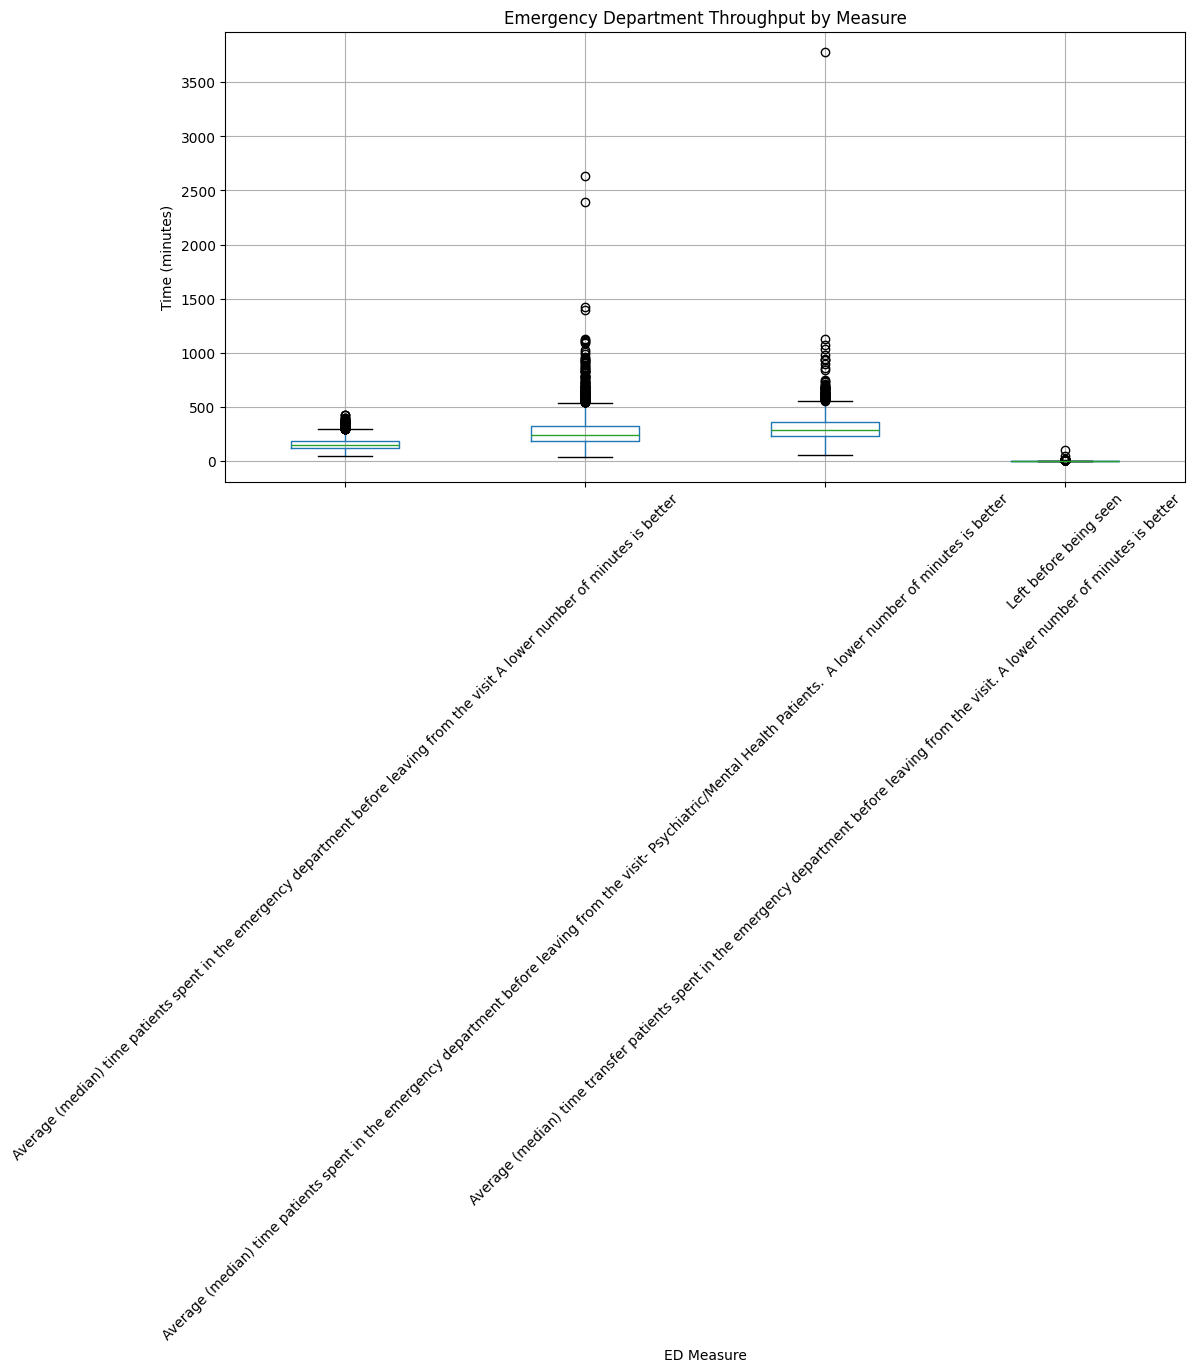

In [15]:
import matplotlib.pyplot as plt

ed_df_clean.boxplot(
    column='score',
    by='measure',
    figsize=(12,6),
    rot=45
)

plt.title('Emergency Department Throughput by Measure')
plt.suptitle('')
plt.xlabel('ED Measure')
plt.ylabel('Time (minutes)')
plt.show()